### Librerias

In [165]:
import pymysql
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression



### Validación estadística de los valores Unknown

In [93]:
data_path = r"/Users/GPSantana/Documents/IT_Academy/IT_Academy Simulador/ProjecteData/Equip_21/Data/Bronze_BANK_marketing_260126.csv"

In [94]:
df = pd.read_csv(
    data_path,
    encoding="utf-8"
)

In [95]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
2,3,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
3,4,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
4,5,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes


In [96]:
contact_share = (
    df["contact"]
    .value_counts(normalize=True)
    .reset_index()
)

In [97]:
contact_share.columns = ["contact", "share"]
contact_share["share_pct"] = contact_share["share"] * 100

contact_share


,contact,share,share_pct
0,cellular,0.721495,72.149482
1,unknown,0.209038,20.903801
2,telephone,0.069467,6.946718


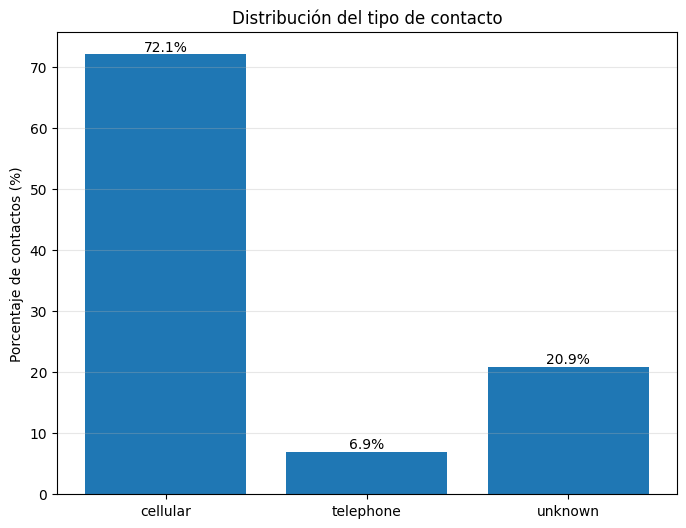

In [98]:
order = ["cellular", "telephone", "unknown"]
contact_share["contact"] = pd.Categorical(
    contact_share["contact"], categories=order, ordered=True
)
contact_share = contact_share.sort_values("contact")

plt.figure(figsize=(8,6))
bars = plt.bar(contact_share["contact"], contact_share["share_pct"])

plt.ylabel("Porcentaje de contactos (%)")
plt.title("Distribución del tipo de contacto")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.show()

### Hipotesis

Hipótesis sobre el origen del tipo de valor 'unknown': Datos faltantes no aleatorios; la ausencia del valor está relacionada con el comportamiento del cliente o con el resultado.
 - Los valores 'unknown' no son iguales a los valores del tipo Null. En la base de datos null está definido de forma inequívoca

### Cómo cambia el CR dependiendo del tipo de contacto?

In [99]:
df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})

In [100]:
summary_contact = (
    df.groupby("contact")
      .agg(
          total_clients=("deposit", "count"),
          success=("deposit", "sum"),
          success_rate=("deposit", "mean"),
      )
      .reset_index()
)


In [101]:

summary_contact["success_rate_pct"] = summary_contact["success_rate"] * 100
summary_contact

,contact,total_clients,success,success_rate,success_rate_pct
0,cellular,7935,4372,0.550977,55.097669
1,telephone,764,390,0.510471,51.047120
2,unknown,2299,531,0.230970,23.096999


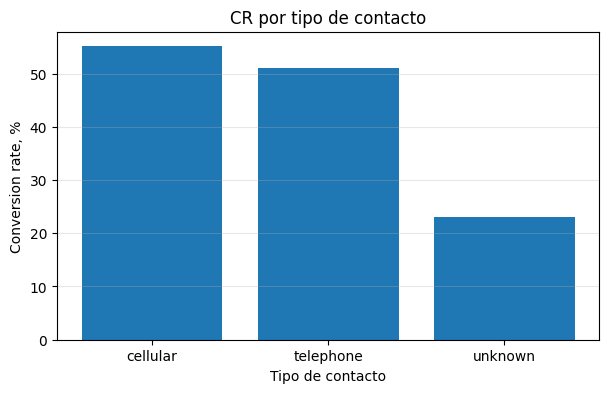

In [102]:
order = ["cellular", "telephone", "unknown"]
summary_contact["contact"] = pd.Categorical(summary_contact["contact"], categories=order, ordered=True)
summary_contact = summary_contact.sort_values("contact")

plt.figure(figsize=(7,4))
plt.bar(summary_contact["contact"], summary_contact["success_rate_pct"])
plt.xlabel("Tipo de contacto")
plt.ylabel("Conversion rate, %")
plt.title("CR por tipo de contacto")
plt.grid(axis="y", alpha=0.3)
plt.show()

Muestra su propio patrón de comportamiento del cliente en el grupo desconocido, lo que confirma la hipótesis de que se trata de un tipo de comunicación separado, pero aún desconocido y sin nombre. 

### Analisis adicional métricas de comportamiento para el grupo unknown

In [103]:
df["contact_group"] = np.where(df["contact"].eq("unknown"), "unknown", "known")

In [104]:
metrics = ["duration", "campaign", "pdays", "previous"]
for col in metrics:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [105]:
behavior_summary = (
    df.groupby("contact_group")[metrics]
      .agg(["count", "mean", "median", "std"])
)

behavior_summary.columns = [f"{m}_{stat}" for m, stat in behavior_summary.columns]
behavior_summary = behavior_summary.reset_index()

behavior_summary


,contact_group,duration_count,duration_mean,duration_median,duration_std,campaign_count,campaign_mean,campaign_median,campaign_std,pdays_count,pdays_mean,pdays_median,pdays_std,previous_count,previous_mean,previous_median,previous_std
0,known,8699,376.520979,265.0,337.695728,8699,2.440280,2.0,2.514152,8699,64.570755,-1.0,116.845320,8699,1.050236,0.0,2.504240
1,unknown,2299,365.379295,221.0,386.291702,2299,2.747281,2.0,3.392908,2299,2.716833,-1.0,46.430866,2299,0.038278,0.0,0.898851


In [106]:
behavior_by_contact = (
    df.groupby("contact")[metrics]
      .agg(["count", "mean", "median", "std"])
)

behavior_by_contact.columns = [f"{m}_{stat}" for m, stat in behavior_by_contact.columns]
behavior_by_contact = behavior_by_contact.reset_index()

behavior_by_contact

,contact,duration_count,duration_mean,duration_median,duration_std,campaign_count,campaign_mean,campaign_median,campaign_std,pdays_count,pdays_mean,pdays_median,pdays_std,previous_count,previous_mean,previous_median,previous_std
0,cellular,7935,378.745558,267.0,332.783265,7935,2.389288,2.0,2.422962,7935,65.562949,-1.0,117.645168,7935,1.049275,0.0,2.464206
1,telephone,764,353.416230,244.0,384.514239,764,2.969895,2.0,3.271528,764,54.265707,-1.0,107.721201,764,1.060209,0.0,2.889224
2,unknown,2299,365.379295,221.0,386.291702,2299,2.747281,2.0,3.392908,2299,2.716833,-1.0,46.430866,2299,0.038278,0.0,0.898851


In [107]:
# Берем средние
means = (
    df.groupby("contact_group")[metrics]
      .mean()
      .rename(index={"known": "known_mean", "unknown": "unknown_mean"})
)

means

,duration,campaign,pdays,previous
contact_group,,,,
known_mean,376.520979,2.440280,64.570755,1.050236
unknown_mean,365.379295,2.747281,2.716833,0.038278


In [108]:
# % разница: (unknown - known) / known
pct_diff = ((means.loc["unknown_mean"] - means.loc["known_mean"]) / means.loc["known_mean"]) * 100
pct_diff = pct_diff.to_frame("unknown_vs_known_mean_%").reset_index().rename(columns={"index": "metric"})

pct_diff

,metric,unknown_vs_known_mean_%
0,duration,-2.959114
1,campaign,12.580559
2,pdays,-95.792471
3,previous,-96.355341


### Resumen

- Duración media de llamadas 'unknown' un poco menos en −3%

- Número de contactos (campaign) más alto (+12.6%)

- "pdays" casi siempre esta relacionado a 0 o −1 (−96%)

- "previous" casi siempre ausente (−96%)

Los resultados sugieren que la categoría “unknown” no es aleatoria y presenta un patrón de comportamiento diferenciado, consistente con un mecanismo de missingness no completamente aleatorio.

<Figure size 700x400 with 0 Axes>

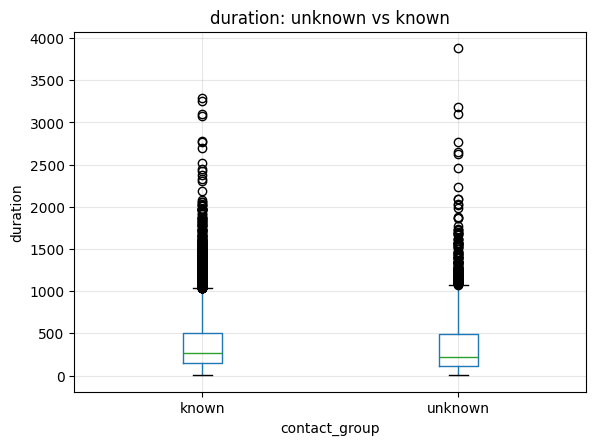

<Figure size 700x400 with 0 Axes>

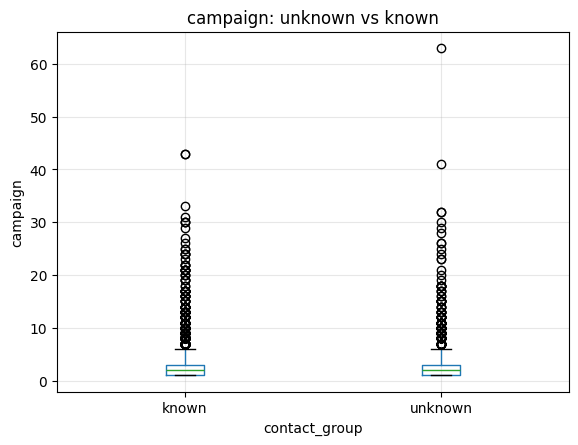

<Figure size 700x400 with 0 Axes>

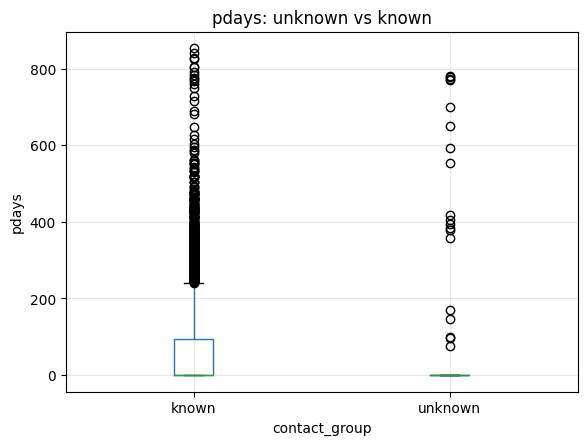

<Figure size 700x400 with 0 Axes>

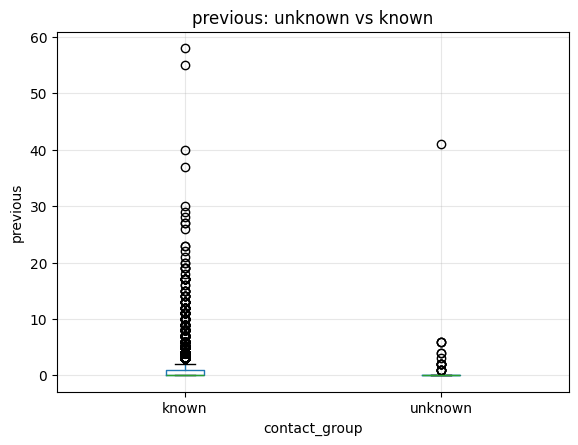

In [109]:
for col in metrics:
    plt.figure(figsize=(7,4))
    df.boxplot(column=col, by="contact_group")
    plt.title(f"{col}: unknown vs known")
    plt.suptitle("")  # убрать авто-заголовок pandas
    plt.xlabel("contact_group")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

In [110]:
behavior_unknown_with_cr = (
    df[df["contact_group"] == "unknown"]
    .groupby("deposit")[metrics]
    .agg(["count", "mean", "median"])
)
behavior_unknown_with_cr
 

duration                    campaign                  pdays            \
           count        mean median    count      mean median count      mean   
deposit                                                                         
0           1768  222.688348  166.0     1768  2.829751    2.0  1768  1.645928   
1            531  840.478343  768.0      531  2.472693    2.0   531  6.282486   

               previous                   
        median    count      mean median  
deposit                                   
0         -1.0     1768  0.035068    0.0  
1         -1.0      531  0.048964    0.0

### Resumen

El análisis muestra que el tipo de contacto está asociado con diferencias en la tasa de conversión, siendo el canal cellular el que presenta el mejor desempeño relativo.
Adicionalmente, el grupo “unknown” representa una proporción relevante de los datos y muestra un patrón de comportamiento claramente diferenciado respecto a los contactos conocidos.
Estas evidencias sugieren que “unknown” no debe tratarse como un valor faltante aleatorio, sino como una categoría con características propias, consistente con un mecanismo de tipo MNAR.
Por tanto, se recomienda analizar este grupo por separado y considerar su impacto específico en la interpretación de los resultados de la campaña.

Con base en este análisis, se decidió tomar en cuenta los valores de la categoría “unknown” y renombrar los datos a "low_quality"

## Valoración del impacto por tipo de contacto

#### Conexión DB

In [111]:
try:
    conn = pymysql.connect(
        host='212.227.90.6',
        user='Equipo21',
        password= 'E1q2u3i4p5o21',
        database='Equip_21',
    )
    print("✅ Conexión establecida con PyMySQL")
except Exception as e:
    print("❌ Error:", e)

✅ Conexión establecida con PyMySQL


In [112]:
query= "SHOW TABLES"

df=pd.read_sql(query,conn)

df

C:\Users\GPSantana\AppData\Local\Temp\ipykernel_8400\3889364871.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,Tables_in_Equip_21
0,BANK_marketing
1,BANK_marketing_dedup
2,BANK_marketing_deduplicated


In [113]:
query = "SELECT * FROM BANK_marketing"

df = pd.read_sql(query, conn)

conn.close()

C:\Users\GPSantana\AppData\Local\Temp\ipykernel_8400\4031327985.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [114]:
df.head()

,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343,1,0,low_quality,5,may,1042,1,-1,0,unknown,1
1,2,59,admin.,married,secondary,0,2343,1,0,low_quality,5,may,1042,1,-1,0,unknown,1
2,69,40,services,married,primary,0,-9,1,0,low_quality,15,may,920,2,-1,0,unknown,1
3,3,56,admin.,married,secondary,0,45,0,0,low_quality,5,may,1467,1,-1,0,unknown,1
4,4,41,technician,married,secondary,0,1270,1,0,low_quality,5,may,1389,1,-1,0,unknown,1


In [115]:
conversion_by_contact = (
    pd.crosstab(df['contact'], df['deposit'], normalize='index') * 100
)

conversion_by_contact

deposit,0,1
contact,,
cellular,44.902331,55.097669
low_quality,76.903001,23.096999
telephone,48.952880,51.047120


In [117]:
# Diferencia absoluta de conversión (impacto real)

conversion_rate.max() - conversion_rate.min()

# la diferencia entre cellular y low_quality es de 32 puntos porcentuales

np.float64(32.00066986194101)

In [156]:
contact_impact = (
    df.groupby("contact")
      .agg(
          volume=("deposit", "count"),
          conversions=("deposit", "sum"),
          conversion_rate=("deposit", "mean")
      )
      .reset_index()
)

contact_impact["conversion_rate"] *= 100
contact_impact

,contact,volume,conversions,conversion_rate
0,cellular,7935,4372,55.097669
1,low_quality,2299,531,23.096999
2,telephone,764,390,51.047120


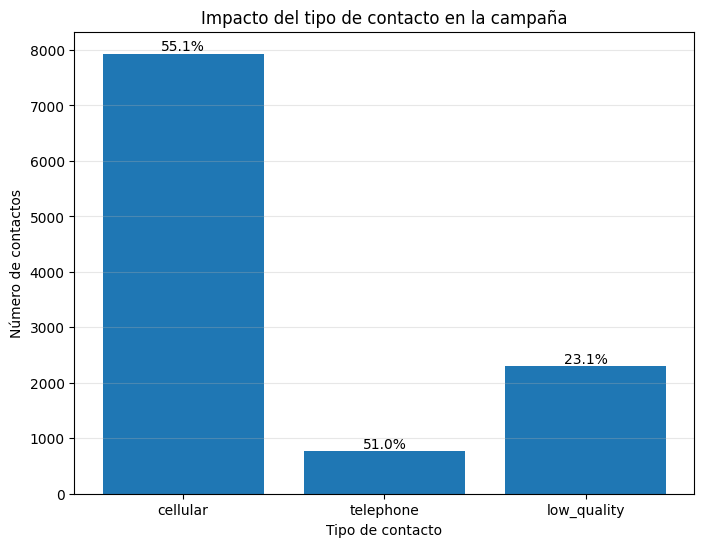

In [157]:
order = ["cellular", "telephone", "low_quality"]
contact_impact["contact"] = pd.Categorical(
    contact_impact["contact"],
    categories=order,
    ordered=True
)
contact_impact = contact_impact.sort_values("contact")

plt.figure(figsize=(8,6))

bars = plt.bar(
    contact_impact["contact"],
    contact_impact["volume"]
)

plt.ylabel("Número de contactos")
plt.xlabel("Tipo de contacto")
plt.title("Impacto del tipo de contacto en la campaña")

# Añadir etiquetas con la tasa de conversión
for bar, rate in zip(bars, contact_impact["conversion_rate"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.show()

## Test's Estadísticos

In [118]:
#  Chi2, sirve para validar la H0 sobre la independencia de las variables "contact" y "deposit"

chi2, p, _, _ = chi2_contingency(
    pd.crosstab(df['contact'], df['deposit'])
)

p

 # p < 0.05 "rechaza H0", lo que significa que el tipo de contacto impacta a la conversión

np.float64(4.128134359441032e-160)

In [153]:
# Cramer´s V test, sirve para responder si la relación es debil, media o fuerte
#0.1 → efecto pequeño
#0.3 → efecto medio
#0.5+ → efecto fuerte

contingency = pd.crosstab(df["contact"], df["deposit"])
chi2, p, dof, expected = chi2_contingency(contingency)

n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

cramers_v

# el resultado indica que el efecto es bajo–moderado, muy cercano a moderado por lo que el tipo de contacto
# tiene un impacto real y relevante, aunque no extremo, en la tasa de conversión.

np.float64(0.2583382307062964)

Aunque la relación entre el tipo de contacto y deposit es estadísticamente muy significativa, su tamaño de efecto es bajo-moderado, lo que indica que el canal de contacto influye en la probabilidad de conversión, pero no es el único factor determinante.

In [154]:
categorical_vars = [
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "credit_default",
    "contact",
    "poutcome",
    "month"
]


In [159]:
def chi2_cramers_v(df, var, target="deposit"):
    contingency = pd.crosstab(df[var], df[target])

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.sum().sum()
    r, k = contingency.shape

    cramer_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

    return p, cramer_v


In [158]:
results = []

for var in categorical_vars:
    p_value, cramer_v = chi2_cramers_v(df, var)

    results.append({
        "variable": var,
        "p_value": p_value,
        "cramers_v": cramer_v
    })


#### Chi2 + Cramer's V de variables categóricas

Con este test valoramos la relación entre deposit y el resto de variables categóricas

In [122]:
chi2_summary = pd.DataFrame(results)

chi2_summary = chi2_summary.sort_values("cramers_v", ascending=False)

chi2_summary


,variable,p_value,cramers_v
8,month,1.845630e-213,0.305725
7,poutcome,7.810566e-212,0.298298
6,contact,4.128134e-160,0.258338
3,housing,1.356736e-101,0.204053
0,job,1.369022e-72,0.182503
4,loan,2.867543e-31,0.110907
2,education,7.085436e-25,0.100559
1,marital,1.122466e-23,0.098029
5,credit_default,7.186694e-05,0.037856


In [123]:
def interpret_cramers_v(v):
    if v < 0.1:
        return "muy bajo"
    elif v < 0.3:
        return "bajo-moderado"
    elif v < 0.5:
        return "moderado"
    else:
        return "alto"


In [124]:
chi2_summary["impacto"] = chi2_summary["cramers_v"].apply(interpret_cramers_v)


In [125]:
chi2_summary

,variable,p_value,cramers_v,impacto
8,month,1.845630e-213,0.305725,moderado
7,poutcome,7.810566e-212,0.298298,bajo-moderado
6,contact,4.128134e-160,0.258338,bajo-moderado
3,housing,1.356736e-101,0.204053,bajo-moderado
0,job,1.369022e-72,0.182503,bajo-moderado
4,loan,2.867543e-31,0.110907,bajo-moderado
2,education,7.085436e-25,0.100559,bajo-moderado
1,marital,1.122466e-23,0.098029,muy bajo
5,credit_default,7.186694e-05,0.037856,muy bajo


In [126]:
numeric_vars = [
    "age",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "balance"
]


In [127]:
def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)

    gt = sum(xi > yj for xi in x for yj in y)
    lt = sum(xi < yj for xi in x for yj in y)

    return (gt - lt) / (nx * ny)


In [128]:
results_num = []

for var in numeric_vars:
    group_0 = df[df["deposit"] == 0][var].dropna()
    group_1 = df[df["deposit"] == 1][var].dropna()

    stat, p_value = mannwhitneyu(group_0, group_1, alternative="two-sided")

    delta = cliffs_delta(group_1.values, group_0.values)

    results_num.append({
        "variable": var,
        "p_value": p_value,
        "cliffs_delta": delta,
        "mean_no": group_0.mean(),
        "mean_yes": group_1.mean(),
        "median_no": group_0.median(),
        "median_yes": group_1.median()
    })


In [129]:
num_summary = pd.DataFrame(results_num)

num_summary = num_summary.sort_values(
    by="cliffs_delta",
    key=abs,
    ascending=False
)

num_summary


,variable,p_value,cliffs_delta,mean_no,mean_yes,median_no,median_yes
1,duration,0.000000e+00,0.611361,222.795968,537.372379,162.0,426.0
4,previous,1.409356e-127,0.202923,0.530762,1.170603,0.0,0.0
3,pdays,2.114560e-109,0.187800,35.795618,68.719630,-1.0,-1.0
5,balance,3.200264e-59,0.178785,1290.124452,1803.497638,417.0,733.0
2,campaign,8.060126e-40,-0.137886,2.842244,2.140374,2.0,2.0
0,age,1.462909e-01,-0.016001,40.876775,41.666730,39.0,38.0


In [143]:
def interpret_delta(d):
    ad = abs(d)
    if ad < 0.147:
        return "muy bajo"
    elif ad < 0.33:
        return "bajo"
    elif ad < 0.474:
        return "moderado"
    else:
        return "alto"


In [144]:
num_summary["impacto"] = num_summary["cliffs_delta"].apply(interpret_delta)


In [145]:
num_summary

,variable,p_value,cliffs_delta,mean_no,mean_yes,median_no,median_yes,impacto
1,duration,0.000000e+00,0.611361,222.795968,537.372379,162.0,426.0,alto
4,previous,1.409356e-127,0.202923,0.530762,1.170603,0.0,0.0,bajo
3,pdays,2.114560e-109,0.187800,35.795618,68.719630,-1.0,-1.0,bajo
5,balance,3.200264e-59,0.178785,1290.124452,1803.497638,417.0,733.0,bajo
2,campaign,8.060126e-40,-0.137886,2.842244,2.140374,2.0,2.0,muy bajo
0,age,1.462909e-01,-0.016001,40.876775,41.666730,39.0,38.0,muy bajo


### Regresión Logística

La regresión logística permite evaluar el efecto del tipo de contacto sobre la conversión controlando por variables operativas y de cliente, identificando posibles relaciones espurias observadas en el análisis bivariado.

In [162]:
target = "deposit"

In [163]:
categorical_features = ["contact", "job","marital","education"]
numeric_features = ["age"]

X = df[categorical_features + numeric_features]
y = df[target]

In [167]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

In [168]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", log_reg)
    ]
)

In [169]:
pipeline.fit(X, y)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [170]:
feature_names = (
    pipeline
    .named_steps["preprocessing"]
    .get_feature_names_out()
)

In [171]:

coefficients = pipeline.named_steps["model"].coef_[0]

In [172]:

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
9,cat__job_student,0.857703
6,cat__job_retired,0.696928
15,cat__education_tertiary,0.482573
11,cat__job_unemployed,0.379617
13,cat__marital_single,0.274361
14,cat__education_secondary,0.206281
16,num__age,0.105623
10,cat__job_technician,-0.114152
5,cat__job_management,-0.131984
2,cat__job_blue-collar,-0.138196


In [173]:
effect_labels = {
    "weak": "débil",
    "medium": "moderado",
    "strong": "fuerte"
}

In [174]:
def classify_effect(or_value):
    if 0.95 <= or_value <= 1.05:
        return effect_labels["weak"]
    elif (0.80 <= or_value < 0.95) or (1.05 < or_value <= 1.25):
        return effect_labels["medium"]
    else:  # or_value < 0.80 or or_value > 1.25
        return effect_labels["strong"]

In [175]:
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df["effect_strength"] = coef_df["odds_ratio"].apply(classify_effect)

coef_df

,feature,coefficient,odds_ratio,effect_strength
9,cat__job_student,0.857703,2.357738,fuerte
6,cat__job_retired,0.696928,2.007575,fuerte
15,cat__education_tertiary,0.482573,1.620238,fuerte
11,cat__job_unemployed,0.379617,1.461725,fuerte
13,cat__marital_single,0.274361,1.315690,fuerte
14,cat__education_secondary,0.206281,1.229099,moderado
16,num__age,0.105623,1.111403,moderado
10,cat__job_technician,-0.114152,0.892122,moderado
5,cat__job_management,-0.131984,0.876355,moderado
2,cat__job_blue-collar,-0.138196,0.870928,moderado


Cambio relativo en odds=(OR−1)×100

cat__contact_low_quality -> coef = -1.29 -> OR = 0.275 -> impacto = fuerte

Contactos low_quality tienen un 72.5% menos de probabilidades de conversión

El efecto es independiente, no espurio

Es el peor canal con diferencia, incluso controlando por duración, perfil, etc.

cat__contact_telephone -> coef = -0.27 -> OR = 0.77 -> impacto = fuerte

El contacto telefónico tiene un 23% menos de probabilidad de conversión frente a cellular (baseline)

El efecto persiste tras el ajuste

Lo que parecía una diferencia moderada en el análisis bivariado, sigue existiendo al controlar por otras variables

No es espurio
Es estructural

## Resumen

A nivel descriptivo, se observan diferencias en las tasas de conversión entre los tipos de contacto: el canal móvil presenta valores más altos en comparación con el contacto telefónico y la categoría low_quality. 
La diferencia absoluta en las tasas de conversión entre los tipos de contacto más y menos efectivos es de 32 puntos porcentuales.

Los resultados de la prueba estadística por chi^2 y Cramer´s V indica una relación entre el tipo de contacto y la apertura de un depósito, lo que elimina la posibilidad de que las diferencias observadas se deban al azar.

Un análisis adicional muestra que la categoría low_quality se caracteriza por un patrón de comportamiento específico y no puede considerarse una omisión aleatoria, lo cual debe tenerse en cuenta al interpretar las diferencias entre canales.

Las diferencias en la conversión están determinadas tanto por el tipo de contacto como por las características del perfil del cliente, y la contribución de estos factores no es uniforme. 

Utilizando un modelo de regresión logística para controlar las diferencias en los perfiles de los clientes, nos muestra que el tipo de contacto se mantiene independientemente asociado a la probabilidad de abrir un depósito, pero la intensidad de este efecto varía entre categorías. 
En concreto, la categoría low_quality tiene un impacto significativamente negativo en comparación con el canal móvil, mientras que el efecto del contacto telefónico es de débil a moderado.

Desde una perspectiva práctica, el contacto móvil demuestra una mayor efectividad en comparación con otros tipos de contacto, lo que permite considerarlo un canal prioritario en una comparación relativa. Al mismo tiempo, el contacto telefónico y los contactos de baja calidad requieren un uso más selectivo y una mayor segmentación de la base de clientes.

El análisis también indica que las diferencias entre canales se explican en parte por las características del perfil del cliente, lo que destaca la necesidad de considerar las variables sociodemográficas al desarrollar estrategias de comunicación. El análisis evalúa las asociaciones entre variables y no establece causalidad; sin embargo, puede servir de base para tomar decisiones operativas informadas y realizar un análisis más profundo.